In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(GenomicRanges)
library(BiocParallel)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
suppressPackageStartupMessages(library(scDblFinder))
library(future)

plan("multicore", workers = 24)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax

### Doublet detection

#### `scDblFinder`

In [2]:
atac <- readRDS('data/atac_common_peak_set_dmg_atlas_qc_filtered.rds')
atac

$`T19-91014`
An object of class Seurat 
378298 features across 8742 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$`T20-90296`
An object of class Seurat 
378298 features across 9578 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$MUV1
An object of class Seurat 
378297 features across 6654 samples within 1 assay 
Active assay: ATAC (378297 features, 0 variable features)
 2 layers present: counts, data

$MUV16
An object of class Seurat 
378298 features across 2645 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$MUV35
An object of class Seurat 
378298 features across 6893 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

$MUV86
An object of class Seurat 
378298 features across 5506 samples within 1 assay 
Active assay: ATAC

In [3]:
atac_merged <- merge(atac[[1]], y = unlist(atac[2:length(atac)]))
bp <- MulticoreParam(12, RNGseed=1234)
doublets_atac <- scDblFinder(GetAssayData(atac_merged, slot="counts"), 
                                samples=atac_merged$SampleID, 
                                clusters=TRUE, aggregateFeatures=TRUE, nfeatures=25, 
                                processing="normFeatures",
                                BPPARAM=bp)
doublets_atac

Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."
Assuming the input to be a matrix of counts or expected counts.

R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 s

class: SingleCellExperiment 
dim: 378298 43608 
metadata(2): scDblFinder.stats scDblFinder.threshold
assays(1): counts
rownames(378298): chr1-9729-10741 chr1-15764-16590 ...
  KI270721.1-46484-47618 KI270726.1-13856-14767
rowData names(0):
colnames(43608): atac_T19-91014_AAACGAAAGACCCTAT-1
  atac_T19-91014_AAACGAAAGCGTTGCC-1 ...
  atac_P-6255_S-8500_TTTGGCCCACAGTTAC-1
  atac_P-6255_S-8500_TTTGTGTCAACGTAGG-1
colData names(9): scDblFinder.sample scDblFinder.cluster ...
  scDblFinder.mostLikelyOrigin scDblFinder.originAmbiguous
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [4]:
atac_merged

An object of class Seurat 
378298 features across 43608 samples within 1 assay 
Active assay: ATAC (378298 features, 0 variable features)
 2 layers present: counts, data

In [5]:
head(doublets_atac$scDblFinder.score)
head(doublets_atac$scDblFinder.class)

[1] 0.002426961 0.001284394 0.982575774 0.328079313 0.001355713 0.015990626

[1] singlet singlet doublet singlet singlet singlet
Levels: singlet doublet

In [6]:
atac_merged$scDblFinder.score <- doublets_atac$scDblFinder.score
atac_merged$scDblFinder.class <- doublets_atac$scDblFinder.class

#### `Amulet`

In [7]:
repeats <- GRanges("chr6", IRanges(1000,2000))
# it's better to combine these with mitochondrial and sex chromosomes
otherChroms <- GRanges(c("M","chrM","MT","X","Y","chrX","chrY"),IRanges(1L,width=10^8))
# here since I don't know what chromosome notation you'll be using I've just put them all,
# although this will trigger a warning when combining them:
toExclude <- suppressWarnings(c(repeats, otherChroms))

# Create an empty list to store the amulet scores per sample
amulet_list <- list()

for (i in seq_along(atac)) {
    fragfile <- Fragments(atac[[i]])[[1]]@path
    barcodes <- unname(Fragments(atac[[i]])[[1]]@cells)
    
    res <- amulet(fragfile, regionsToExclude=toExclude, barcodes = barcodes, fullInMemory=TRUE)
    amulet_list[[i]] <- res
    }

11:01:26 PM - Reading full fragments...

11:11:58 PM - Splitting and subsetting barcodes...

11:13:00 PM - Obtaining overlaps...

11:24:02 PM - Reading full fragments...

11:33:22 PM - Splitting and subsetting barcodes...

11:34:10 PM - Obtaining overlaps...

11:45:35 PM - Reading full fragments...

11:48:44 PM - Splitting and subsetting barcodes...

11:49:05 PM - Obtaining overlaps...

11:56:35 PM - Reading full fragments...

11:58:42 PM - Splitting and subsetting barcodes...

11:58:53 PM - Obtaining overlaps...

12:01:57 AM - Reading full fragments...

12:05:28 AM - Splitting and subsetting barcodes...

12:05:52 AM - Obtaining overlaps...

12:13:57 AM - Reading full fragments...

12:15:40 AM - Splitting and subsetting barcodes...

12:15:52 AM - Obtaining overlaps...

12:22:03 AM - Reading full fragments...

12:22:14 AM - Splitting and subsetting barcodes...

12:22:14 AM - Obtaining overlaps...

12:23:29 AM - Reading full fragments...

12:25:42 AM - Splitting and subsetting barcodes..

In [8]:
head(amulet_list, n = 1)

,nFrags,uniqFrags,nAbove2,total.nAbove2,p.value,q.value
,<int>,<int>,<int>,<int>,<dbl>,<dbl>
AAACGAAAGACCCTAT-1,19016,19016,16,99,7.109960e-01,1.000000e+00
AAACGAAAGCGTTGCC-1,14251,14251,1,5,9.999999e-01,1.000000e+00
AAACGAAAGTACAACA-1,58547,58547,18,62,5.340977e-01,1.000000e+00
AAACGAAAGTAGTGTA-1,44294,44294,41,207,3.778549e-06,3.313147e-05
AAACGAAAGTGAATAC-1,12846,12846,1,7,9.999999e-01,1.000000e+00
AAACGAAAGTGCCCTG-1,17846,17846,3,5,9.999927e-01,1.000000e+00
AAACGAAAGTGTAATG-1,14720,14720,2,34,9.999989e-01,1.000000e+00
AAACGAACAAATGCTC-1,20435,20435,4,8,9.999632e-01,1.000000e+00
AAACGAACACGCCGAT-1,10204,10204,1,9,9.999999e-01,1.000000e+00


In [9]:
amulet_atac <- do.call(rbind, amulet_list)
rownames(amulet_atac) <- rownames(atac_merged@meta.data)
amulet_atac

,nFrags,uniqFrags,nAbove2,total.nAbove2,p.value,q.value
,<int>,<int>,<int>,<int>,<dbl>,<dbl>
atac_T19-91014_AAACGAAAGACCCTAT-1,19016,19016,16,99,7.109960e-01,1.000000e+00
atac_T19-91014_AAACGAAAGCGTTGCC-1,14251,14251,1,5,9.999999e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTACAACA-1,58547,58547,18,62,5.340977e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTAGTGTA-1,44294,44294,41,207,3.778549e-06,3.313147e-05
atac_T19-91014_AAACGAAAGTGAATAC-1,12846,12846,1,7,9.999999e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTGCCCTG-1,17846,17846,3,5,9.999927e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTGTAATG-1,14720,14720,2,34,9.999989e-01,1.000000e+00
atac_T19-91014_AAACGAACAAATGCTC-1,20435,20435,4,8,9.999632e-01,1.000000e+00
atac_T19-91014_AAACGAACACGCCGAT-1,10204,10204,1,9,9.999999e-01,1.000000e+00


In [10]:
atac_merged <- AddMetaData(atac_merged, amulet_atac, col.name = c('p.value', 'q.value'))
atac_merged@meta.data

,orig.ident,total,duplicate,chimeric,unmapped,lowmapq,mitochondrial,nonprimary,passed_filters,is__cell_barcode,⋯,TSS.enrichment,TSS.percentile,pct_reads_in_peaks,blacklist_ratio,high.tss,nucleosome_group,scDblFinder.score,scDblFinder.class,p.value,q.value
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<dbl>
atac_T19-91014_AAACGAAAGACCCTAT-1,SeuratProject,37892,15065,1,438,3127,45,5,19211,1,⋯,6.585061,0.95,73.68174,0.005604587,High,NS < 4,0.002426961,singlet,7.109960e-01,1.000000e+00
atac_T19-91014_AAACGAAAGCGTTGCC-1,SeuratProject,22601,6146,0,246,1761,1,3,14444,1,⋯,5.515696,0.89,65.59817,0.007014953,High,NS < 4,0.001284394,singlet,9.999999e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTACAACA-1,SeuratProject,88086,16394,15,1025,10885,82,198,59487,1,⋯,3.993602,0.75,26.92857,0.009146758,High,NS < 4,0.982575774,doublet,5.340977e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTAGTGTA-1,SeuratProject,67957,14538,11,877,7296,22,43,45170,1,⋯,4.558136,0.80,43.59088,0.006111504,High,NS < 4,0.328079313,singlet,3.778549e-06,3.313147e-05
atac_T19-91014_AAACGAAAGTGAATAC-1,SeuratProject,21580,5723,1,213,2597,9,12,13025,1,⋯,5.640890,0.90,63.17083,0.006865955,High,NS < 4,0.001355713,singlet,9.999999e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTGCCCTG-1,SeuratProject,28527,7851,0,319,2382,16,6,17953,1,⋯,4.117904,0.76,42.65582,0.005032502,High,NS < 4,0.015990626,singlet,9.999927e-01,1.000000e+00
atac_T19-91014_AAACGAAAGTGTAATG-1,SeuratProject,27213,9888,2,323,2030,71,9,14890,1,⋯,5.440663,0.88,71.52451,0.006380264,High,NS < 4,0.005395977,singlet,9.999989e-01,1.000000e+00
atac_T19-91014_AAACGAACAAATGCTC-1,SeuratProject,32533,8763,0,352,2536,206,14,20662,1,⋯,6.047649,0.92,59.78608,0.005934718,High,NS < 4,0.011626394,singlet,9.999632e-01,1.000000e+00
atac_T19-91014_AAACGAACACGCCGAT-1,SeuratProject,17835,5161,3,213,1943,74,16,10425,1,⋯,5.198028,0.86,57.32374,0.006086074,High,NS < 4,0.003789691,singlet,9.999999e-01,1.000000e+00


In [11]:
atac_merged$scDblFinder.p <- 1-colData(doublets_atac)[row.names(amulet_atac), "scDblFinder.score"]
atac_merged$combined <- apply(atac_merged@meta.data[,c("scDblFinder.p", "p.value")], 
                              1, FUN=function(x){
  x[x<0.001] <- 0.001 # prevent too much skew from very small or 0 p-values
  suppressWarnings(aggregation::fisher(x))
})

In [12]:
saveRDS(atac_merged, 'data/atac_common_peak_set_dmg_atlas_qc_filtered_dbl_scores_merged.rds')

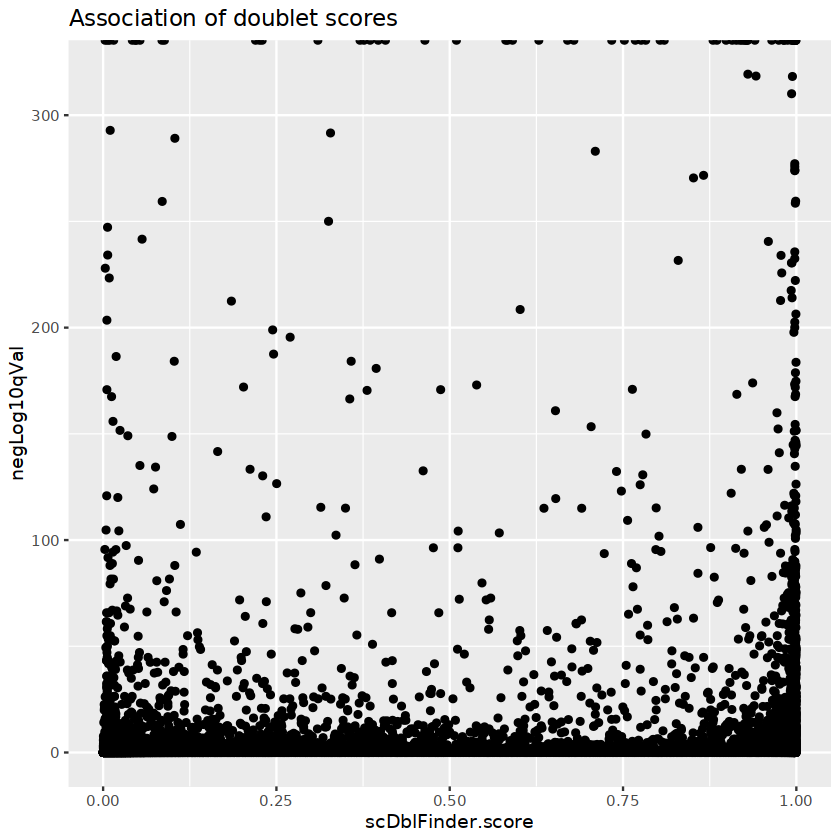

In [13]:
# Compute the negative logarithm of q.value
atac_merged$negLog10qVal <- -log10(atac_merged$q.value)

# Create the scatter plot
ggplot(atac_merged@meta.data, aes(x = scDblFinder.score, y = negLog10qVal)) +
  geom_point() +
  labs(title = "Association of doublet scores")